In [42]:
import sys
sys.path.append('/Users/andrepfrommer/Desktop/neural_data_science_project')

from utils.utils import *
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../poisson-gpfa/")
sys.path.append("../poisson-gpfa/funs")

import funs.util as util
import funs.engine as engine

In [43]:
data = load_saved_data("data_with_spikes")

Implement loading the data for each trial for the natural scences session and encapsulating it into a class that matches the poisson GPFA engine.

In [44]:
class GPFADataset:
    """Create a GPFA-compatible dataset from visual coding data.

    Each stimulus presentation is treated as one trial.
    `self.data[trial]["Y"]` has shape (ydim, T).
    """

    def __init__(
        self,
        data=None,
        session_id="B",
        stimulus="natural_scenes",
        duration_min=0.25,
    ):

        # unpack session data
        session = data["sessions"][session_id]
        spikes = np.asarray(session["spikes"], dtype=float)
        t = np.asarray(session["t"], dtype=float)
        stim_table = session["stim_tables"][stimulus].copy()

        starts = stim_table["start"].astype(int).to_numpy()
        ends = stim_table["end"].astype(int).to_numpy()
        durations = ends - starts

        # timestep in milliseconds
        dt_ms = float(np.median(np.diff(t))) * 1000.0
        dt_sec = dt_ms / 1000.0

        # filter out trials shorter than duration_min (given in seconds)
        min_duration_samples = int(round((duration_min * 1000.0) / dt_ms))
        valid_trials = durations >= min_duration_samples
        starts = starts[valid_trials]
        ends = ends[valid_trials]
        durations = durations[valid_trials]
        stim_table = stim_table[valid_trials].reset_index(drop=True)

        # GPFA needs fixed-length trials, so use the lowest number of samples across all trials
        T = int(np.min(durations))

        # Somehow need even nr of bins TODO: why??
        if T % 2 == 1:
            T = T - 1

        # only get running speed array
        running_speed = np.asarray(session["running_speed"][0], dtype=float)  # shape (time,)

        # Keep all stimulus-table metadata except start/end in each trial dict.
        stim_metadata_cols = [c for c in stim_table.columns if c not in ("start", "end")]

        trials = []
        trial_durs = []

        # loop over stimuli (trials)
        for _, row in stim_table.iterrows():
            start_idx = int(row["start"])
            stop_idx = start_idx + T

            # Get the spike counts for this trial
            Y = spikes[:, start_idx:stop_idx]  # shape (ydim, T)

            # Robust spike-time extraction from deconvolved amplitudes.
            # Any positive finite amplitude contributes at least one spike event.
            spike_time = []
            for neuron in range(spikes.shape[0]):
                trial_trace = Y[neuron]
                nz = np.flatnonzero(np.isfinite(trial_trace) & (trial_trace > 0))
                if nz.size == 0:
                    spike_time.append(np.array([], dtype=float))
                    continue

                counts = np.maximum(1, np.rint(trial_trace[nz]).astype(int))
                spike_bins = np.repeat(nz, counts)
                spike_time.append(spike_bins * dt_sec)

            trial_speed = running_speed[start_idx:stop_idx]

            trial_dict = {
                "Y": Y,
                "spike_time": spike_time,
                "start_idx": start_idx,
                "end_idx": stop_idx,
                "running_speed": trial_speed,
            }

            # Add all available parameters
            for col in stim_metadata_cols:
                trial_dict[col] = row[col]

            trials.append(trial_dict)
            trial_durs.append(T * dt_sec)

        self.data = trials
        self.trial_durs = trial_durs
        self.trialDur = T * dt_ms
        self.binSize = dt_ms
        self.numTrials = len(trials)
        self.ydim = spikes.shape[0]
        self.T = T
        self.session_id = session_id
        self.stimulus = stimulus
        self.available_parameters = stim_metadata_cols

In [45]:
data_natural_scenes = GPFADataset(
    data=data,
    session_id="B",
    stimulus="natural_scenes",
    duration_min=0.0,
)

In [56]:
data_drifting_gratings = GPFADataset(
    data=data,
    session_id="A",
    stimulus="drifting_gratings",
    duration_min=0.2,
)

In [47]:
data_static_gratings = GPFADataset(
    data=data,
    session_id="B",
    stimulus="static_gratings",
    duration_min=0.25,
)

In [48]:
data_locally_sparse_noise = GPFADataset(
    data=data,
    session_id="C",
    stimulus="locally_sparse_noise",
    duration_min=0.25,
)

In [49]:
print(data_natural_scenes.numTrials) # nr of different frames presented
print(data_natural_scenes.ydim) # nr of neurons
print(data_natural_scenes.T) # nr of time bins per trial
print(data_natural_scenes.trialDur) # rounded trial duration in milliseconds
print(data_natural_scenes.binSize) # bin size in milliseconds
print(data_natural_scenes.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_natural_scenes.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_natural_scenes.data[0]['running_speed']) # running speed for the first trial

5950
47
6
199.21875
33.203125
(47, 6)
(1,)
[-5.24924803  4.53951454  1.52292752 -0.36674222 -1.28542471  1.01584566]


In [57]:
print(data_drifting_gratings.numTrials) # nr of different frames presented
print(data_drifting_gratings.ydim) # nr of neurons
print(data_drifting_gratings.T) # nr of time bins per trial
print(data_drifting_gratings.trialDur) # rounded trial duration in milliseconds
print(data_drifting_gratings.binSize) # bin size in milliseconds
print(data_drifting_gratings.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_drifting_gratings.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_drifting_gratings.data[0]['running_speed']) # running speed for the first trial

628
47
58
1925.78125
33.203125
(47, 58)
(2,)
[ 1.2727344  -0.48777509  0.51443249  0.26617509 -1.16882133  5.86523676
 -7.4695282   7.16684103 -1.65278494 -6.43877172  4.22992325  0.94754547
 -2.03360224  5.01908588 -9.31025219  9.1914072  -7.33443451  4.05136871
 -1.24078369 -2.18670797  4.14428234  0.2973364  -0.91482508 -1.57968986
  1.30515218 -0.35472268 -0.98398858 -0.29413208  0.36628532  2.36766815
 -2.48410821  0.25596732  0.36762968 -0.6292218   1.90475631 -1.76088893
 -1.92924249  3.93768835 -1.5141319   0.36506522  1.68821311 -2.84791207
 -0.21939865  0.02486236  1.37349713  3.57753396 -3.50849891 -1.12711287
  0.31235704 -2.66756105  7.80182219 -7.79697037  2.84636331 -0.46299785
 -1.24472129  2.66384983  0.03873559 -1.43724966]


In [51]:
print(data_static_gratings.numTrials) # nr of different frames presented
print(data_static_gratings.ydim) # nr of neurons
print(data_static_gratings.T) # nr of time bins per trial
print(data_static_gratings.trialDur) # rounded trial duration in milliseconds
print(data_static_gratings.binSize) # bin size in milliseconds
print(data_static_gratings.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_static_gratings.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_static_gratings.data[0]['running_speed']) # running speed for the first trial

133
47
8
265.625
33.203125
(47, 8)
(1,)
[27.8956871  27.60123253 29.56472397 24.38804245 27.75061989 28.97066689
 29.8886528  30.69490623]


In [52]:
print(data_locally_sparse_noise.numTrials) # nr of different frames presented
print(data_locally_sparse_noise.ydim) # nr of neurons
print(data_locally_sparse_noise.T) # nr of time bins per trial
print(data_locally_sparse_noise.trialDur) # rounded trial duration in milliseconds
print(data_locally_sparse_noise.binSize) # bin size in milliseconds
print(data_locally_sparse_noise.data[0]['Y'].shape) # shape of Y (spike counts) for the first trial
print(data_locally_sparse_noise.data[0]['spike_time'][29].shape) # spike times for the first neuron in the first trial
print(data_locally_sparse_noise.data[0]['running_speed']) # running speed for the first trial

212
47
8
265.625
33.203125
(47, 8)
(0,)
[ 1.04065382 -0.40625158  2.57864809 -0.7900213  -0.42878723 -0.07557572
 -0.14110513  0.53344721]


## Fit Poisson GPFA models

In [59]:
# perform cross-validation to find the optimal latent dimensionality for GPFA

xval_natural_scenes = util.crossValidation(
    experiment = data_natural_scenes,
    numTrainingTrials = data_natural_scenes.numTrials - 10,
    numTestTrials = 10,
    maxXdim = 1,
    maxEMiter = 5, 
    batchSize = 5,
    inferenceMethod = "laplace",
    learningMethod = "batch", 
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                    5 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+


KeyboardInterrupt: 

In [61]:
xval_drifting_gratings = util.crossValidation(
    experiment = data_drifting_gratings,
    numTrainingTrials = data_drifting_gratings.numTrials - 10,
    numTestTrials = 10,
    maxXdim = 1,
    maxEMiter = 5, 
    batchSize = 5,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                    5 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:   5 of   5, nPLL: = -22.6639Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/notebooks/../poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


In [62]:
xval_static_gratings = util.crossValidation(
    experiment = data_static_gratings,
    numTrainingTrials = data_static_gratings.numTrials - 10,
    numTestTrials = 10,
    maxXdim = 1,
    maxEMiter = 10, 
    batchSize = 5,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   10 | Max EM iterations:
                                              laplace | Inference Method


+-----------------------------------------------------+
Iteration:  10 of  10, nPLL: = -4.4172Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/notebooks/../poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


In [63]:
xval_locally_sparse_noise = util.crossValidation(
    experiment = data_locally_sparse_noise,
    numTrainingTrials = data_locally_sparse_noise.numTrials - 10,
    numTestTrials = 10,
    maxXdim = 1,
    maxEMiter = 10,
    batchSize = 5,
    inferenceMethod = "laplace",
    learningMethod = "batch",
)

Assessing optimal latent dimensionality will take a long time.
Initializing parameters with Poisson-PCA..
+-------------------- Fit Options --------------------+
                                                    1 | Dimensionality of Latent State
                                                   47 | Dimensionality of Observed State (# neurons)
                                                Batch | EM mode:
                                                   10 | Max EM iterations:
                                              laplace | Inference Method
+-----------------------------------------------------+
Iteration:  10 of  10, nPLL: = -5.1116Performing leave-one-out cross validation...


/Users/andrepfrommer/Desktop/neural_data_science_project/notebooks/../poisson-gpfa/funs/util.py:22: RuntimeWarning: divide by zero encountered in log
  return np.log(np.linalg.det((X+Y)/2)) - 1/2*np.log(np.linalg.det(X.dot(Y)))


## Some plotting functions 

In [ ]:
def plot_grouped_gpfa(
    fit,
    data_gpfa,
    raw_data=None,
    parameter="frame",
    trial_index=0,
    latent_dim=0,
    figsize=(3, 2),
    latent_ylim=(-0.5, 0.5),
    speed_ylim=(-10, 10),
    max_rows=8,
    show_image_panel=None,
):
    """
    Plot trials grouped by a stimulus parameter (e.g. "frame" or "orientation"),
    one row per unique parameter value, sorted ascending.
    """
    if show_image_panel is None:
        show_image_panel = (parameter == "frame")

    ydim, T, trial_dur_ms = data_gpfa.ydim, data_gpfa.T, data_gpfa.trialDur
    t_lat = (np.arange(T) + 0.5) * data_gpfa.binSize
    latent_ticks = np.linspace(*latent_ylim, num=3)
    speed_ticks = np.linspace(*speed_ylim, num=3)
    stimulus_key = getattr(data_gpfa, "stimulus", None)
    templates = (raw_data.get("templates", {}).get(stimulus_key) if raw_data is not None else None)

    # Keep raster/trace panel widths consistent across plotting modes and make
    # the frame panel larger when shown.
    frame_ratio = 2.2
    raster_ratio = 3.0
    trace_ratio = 3.0
    if show_image_panel:
        width_ratios = [frame_ratio, raster_ratio, trace_ratio]
    else:
        width_ratios = [raster_ratio, trace_ratio]

    n_cols = len(width_ratios)

    # Use ratio-scaled figure width so raster panels have stable physical size.
    fig_w = figsize[0] * float(np.sum(width_ratios))

    start_to_postmean = {
        trial["start_idx"]: i
        for i, trial in enumerate(fit.experiment.data)
        if i < len(fit.infRes["post_mean"])
    }

    # Group only trials that were actually fitted and have valid speed.
    param_to_trials = {}
    for tr, trial in enumerate(data_gpfa.data):
        post_mean_idx = start_to_postmean.get(trial.get("start_idx"))
        if post_mean_idx is None:
            continue
        
        val = trial.get(parameter)
        if val is None:
            continue
        if hasattr(val, "item"):
            val = val.item()

        param_to_trials.setdefault(val, []).append(tr)


    unique_params = sorted(param_to_trials.keys())
    if max_rows:
        unique_params = unique_params[:max_rows]

    n_rows = len(unique_params)

    fig, axs = plt.subplots(
        n_rows,
        n_cols,
        figsize=(fig_w, figsize[1] * n_rows),
        gridspec_kw={"width_ratios": width_ratios},
        squeeze=False,
    )

    for row, val in enumerate(unique_params):
        ids = param_to_trials[val]
        tr = ids[trial_index] if trial_index < len(ids) else None
        col = 0

        if show_image_panel:
            ax_img = axs[row, col]
            col += 1
            show_template = False
            frame_idx = None
            if templates is not None:
                try:
                    frame_idx = int(val)
                    show_template = 0 <= frame_idx < len(templates)
                except (TypeError, ValueError):
                    show_template = False

            if tr is not None and show_template:
                ax_img.imshow(templates[frame_idx], cmap="gray", aspect="auto")
            else:
                ax_img.text(0.5, 0.5, f"{parameter}={val}", ha="center", va="center", fontsize=9)
                ax_img.set_facecolor("0.95")

            ax_img.set_xticks([])
            ax_img.set_yticks([])
            ax_img.set_ylabel(f"{parameter}={val}", fontsize=9)

        ax_raster, ax_trace = axs[row, col], axs[row, col + 1]

        if tr is None:
            ax_raster.axis("off")
            ax_trace.axis("off")
            continue

        trial = data_gpfa.data[tr]
        post_mean_idx = start_to_postmean[trial["start_idx"]]

        # Raster
        spike_times_ms = [np.asarray(st).reshape(-1) * 1000.0 for st in trial["spike_time"]]
        ax_raster.eventplot(spike_times_ms, orientation="horizontal", colors="black")
        ax_raster.set_xlim(0, trial_dur_ms)
        ax_raster.set_ylim(-1, ydim)
        ax_raster.set_yticks([])
        if not show_image_panel:
            ax_raster.set_ylabel(f"{parameter}={val}", fontsize=9)

        # Latent + speed (trial is guaranteed to be in fit and have speed)
        latent = np.asarray(fit.infRes["post_mean"][post_mean_idx][latent_dim, :], dtype=float)
        ax_trace.plot(t_lat, latent, color="red", lw=1.8)
        ax_trace.set_xlim(0, trial_dur_ms)
        ax_trace.set_ylim(latent_ylim)
        ax_trace.set_yticks(latent_ticks)
        ax_trace.set_yticklabels([f"{v:.2f}" for v in latent_ticks])
        ax_trace.set_ylabel(rf"latent $x_{{{latent_dim}}}(t)$", fontsize=8, color="red")
        ax_trace.tick_params(axis="y", labelcolor="red")

        speed = np.asarray(trial.get("running_speed", []), dtype=float).reshape(-1)
        ax_speed = ax_trace.twinx()
        t_speed = (np.arange(speed.size) + 0.5) * (trial_dur_ms / speed.size)
        ax_speed.plot(t_speed, speed, color="blue", lw=1.2, alpha=0.9)
        ax_speed.set_ylim(speed_ylim)
        ax_speed.set_yticks(speed_ticks)
        ax_speed.set_yticklabels([f"{v:.1f}" for v in speed_ticks])
        ax_speed.set_ylabel("speed", fontsize=8, color="blue")
        ax_speed.tick_params(axis="y", labelcolor="blue")

        if row == 0:
            ax_raster.set_title("raster", fontsize=9)
            ax_trace.set_title("latent & speed", fontsize=9)
        if row == n_rows - 1:
            ax_raster.set_xlabel("time (ms)")
            ax_trace.set_xlabel("time (ms)")

    fig.tight_layout()
    return fig, axs

## 1. Evaluate natural scenes fit

In [115]:
# pick the model
fit_natural_scenes = xval_natural_scenes.fits[0]

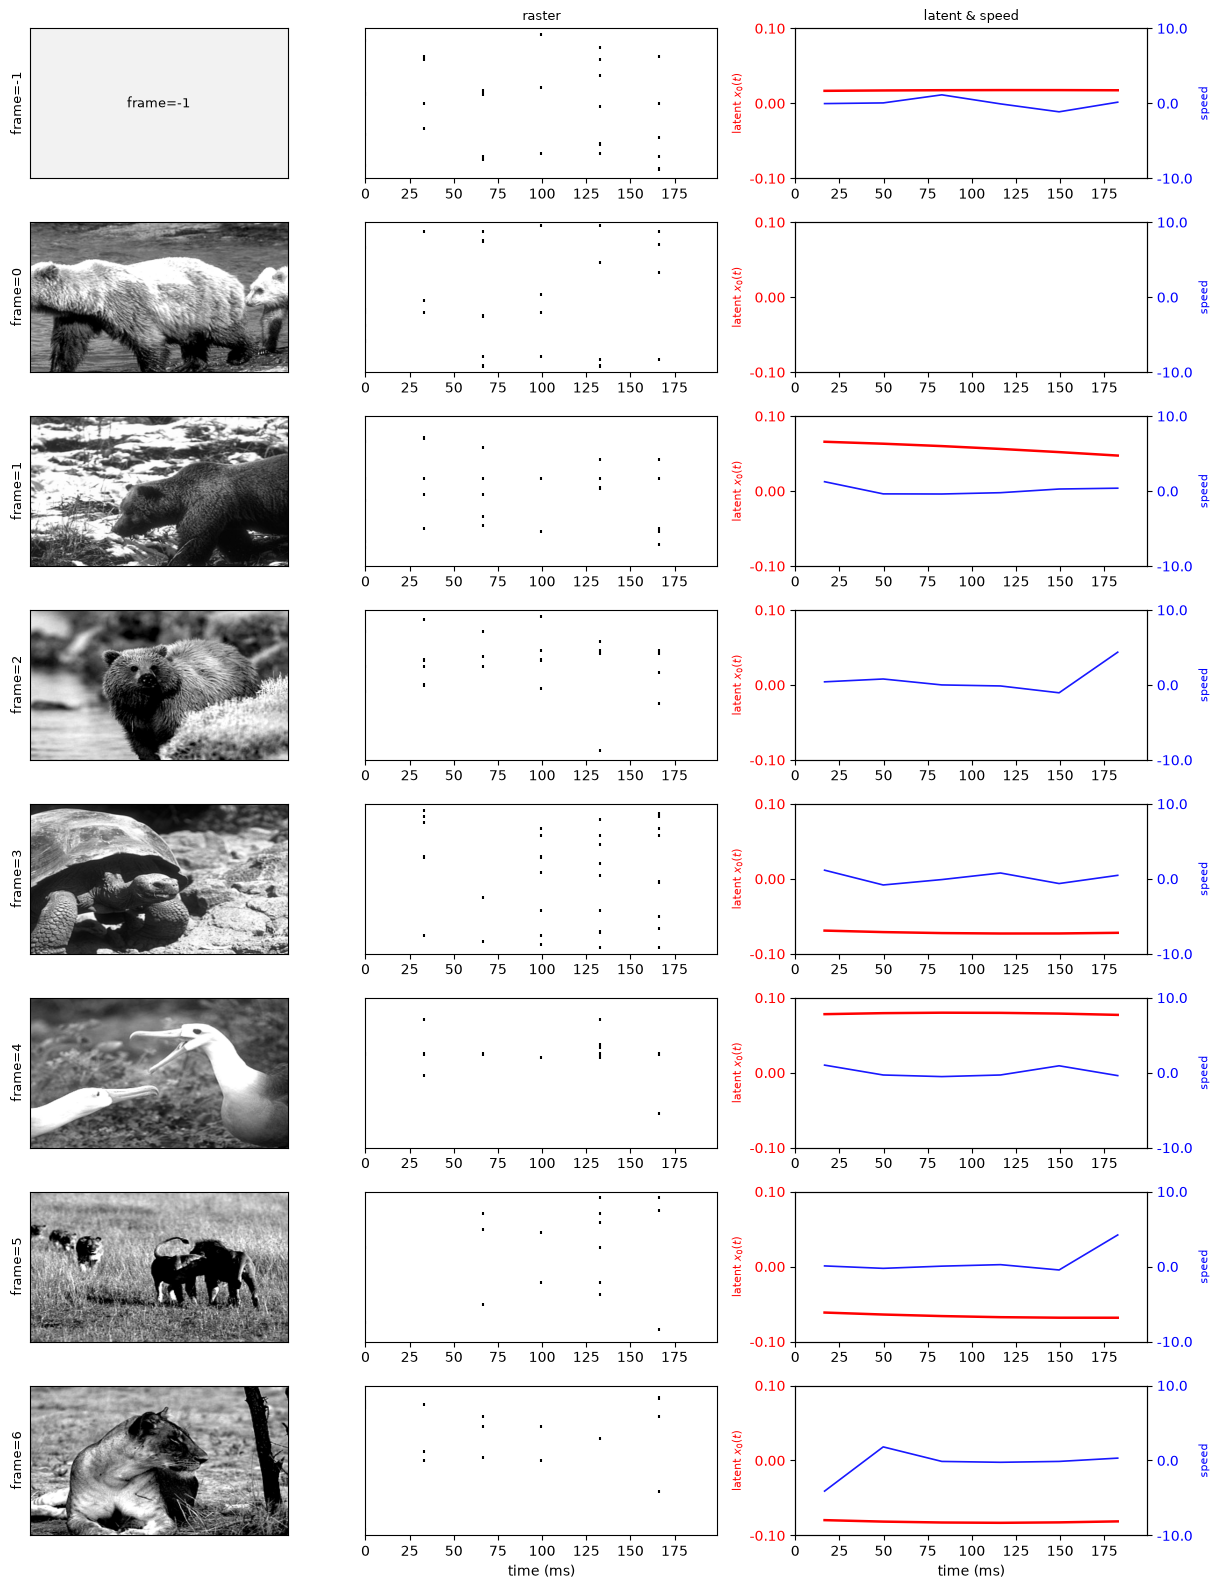

In [116]:
fig, axs = plot_grouped_gpfa(
    fit=fit_natural_scenes,
    data_gpfa=data_natural_scenes,
    raw_data=data,
    parameter="frame",
    trial_index=4,
    latent_dim=0,
    figsize=(1.5, 2),
    latent_ylim=(-0.1, 0.1),
    speed_ylim=(-10, 10)
)
plt.show()

TODO: Why do we sometimes see no latent state here? I guess its because these trials were not in training set

## 2. Evaluate drifiting gratings fit

In [117]:
fit_drifting_gratings = xval_drifting_gratings.fits[-1]

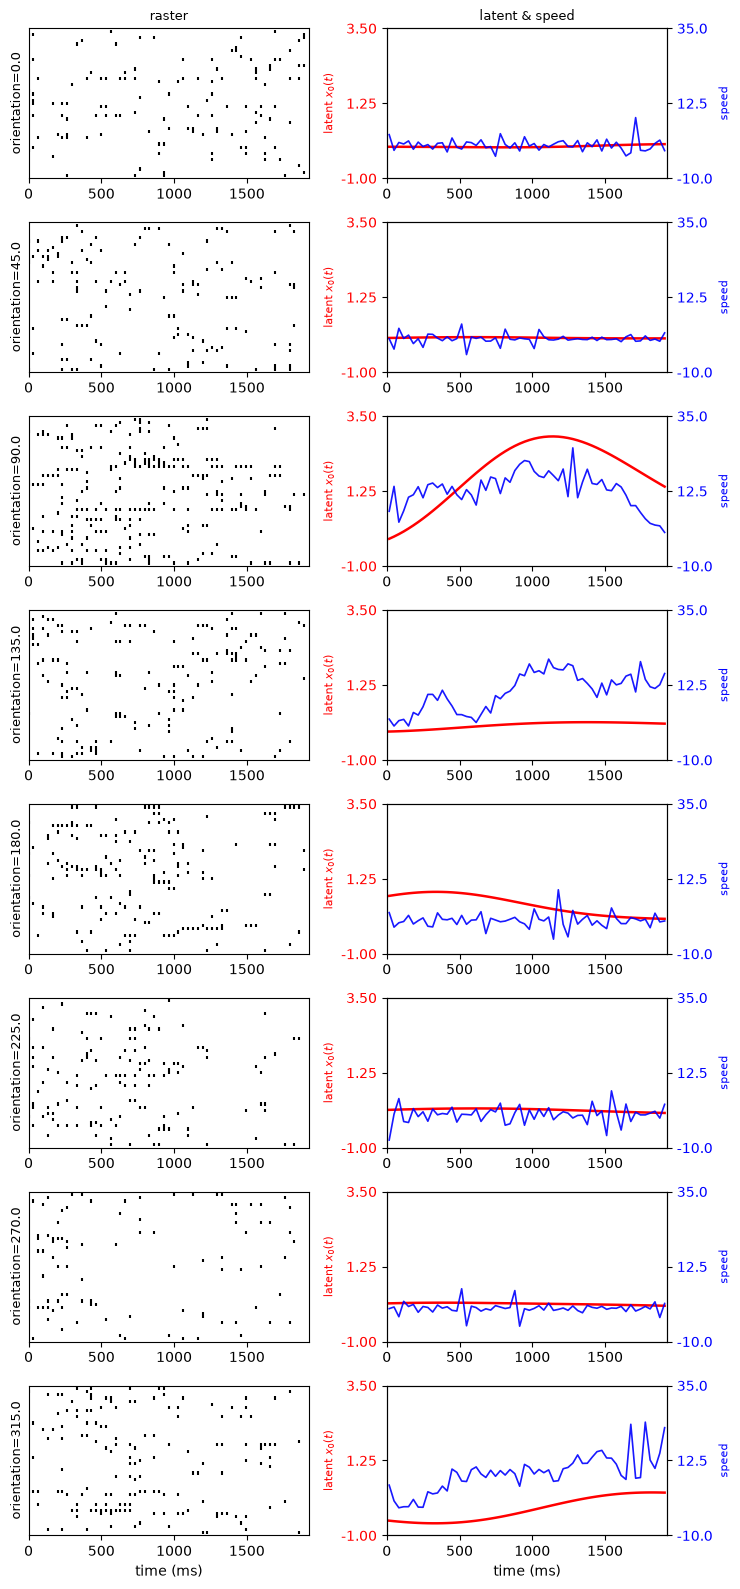

In [118]:
fig, axs = plot_grouped_gpfa(
    fit=fit_drifting_gratings,
    data_gpfa=data_drifting_gratings,
    raw_data=data,
    parameter="orientation",
    trial_index=2,
    latent_dim=0,
    figsize=(1.25, 2),
    latent_ylim=(-1, 3.5),
    speed_ylim=(-10, 35),
)
plt.show()

## 3. Evaluate static gratings fit

In [119]:
fit_static_gratings = xval_static_gratings.fits[-1]

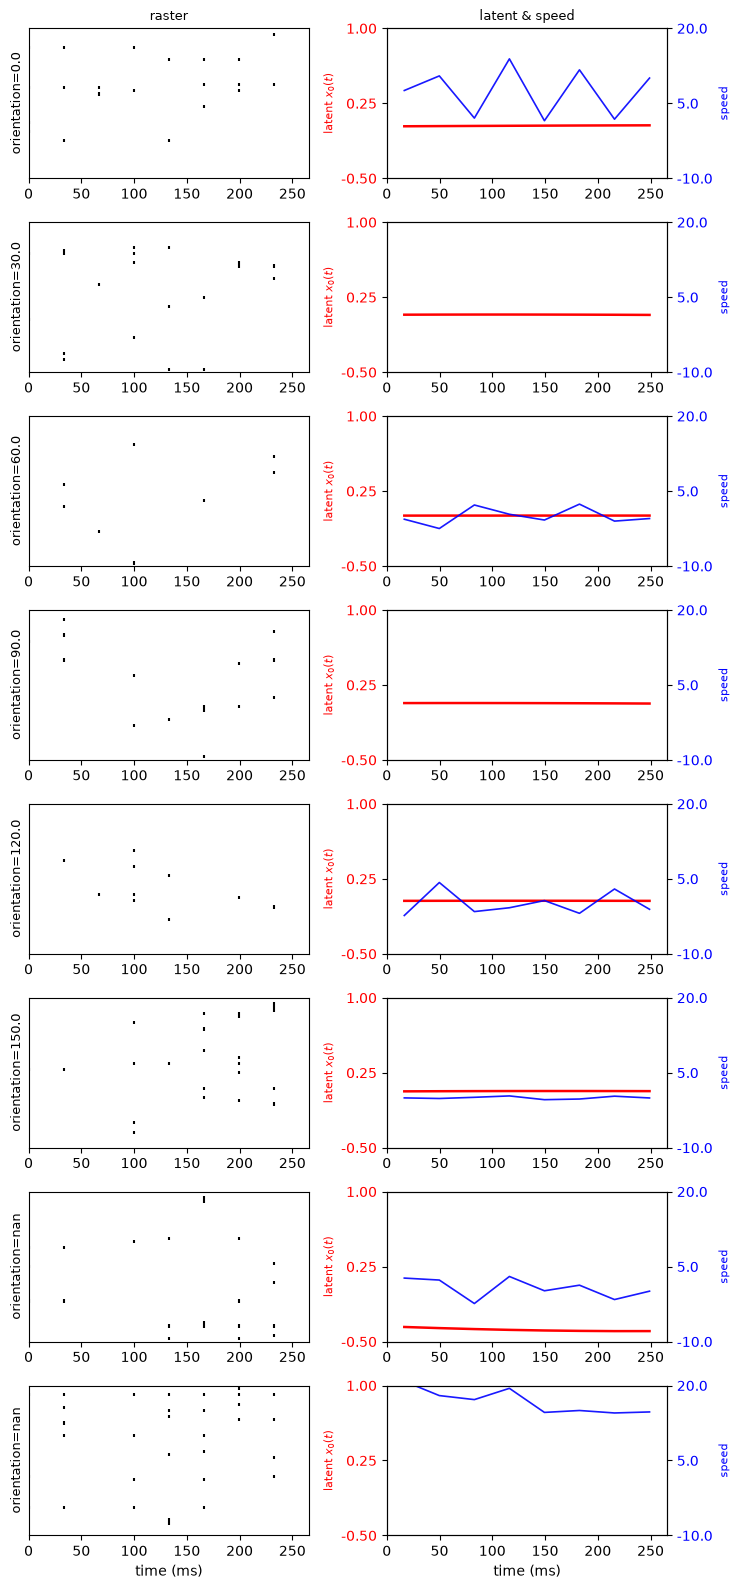

In [121]:
fig, axs = plot_grouped_gpfa(
    fit=fit_static_gratings,
    data_gpfa=data_static_gratings,
    raw_data=data,
    parameter="orientation",
    trial_index=0,
    latent_dim=0,
    figsize=(1.25, 2),
    latent_ylim=(-0.5, 1.0),
    speed_ylim=(-10, 20),
)
plt.show()

## 4. Evaluate locally sparse noise fit

In [122]:
fit_locally_sparse_noise = xval_locally_sparse_noise.fits[-1]

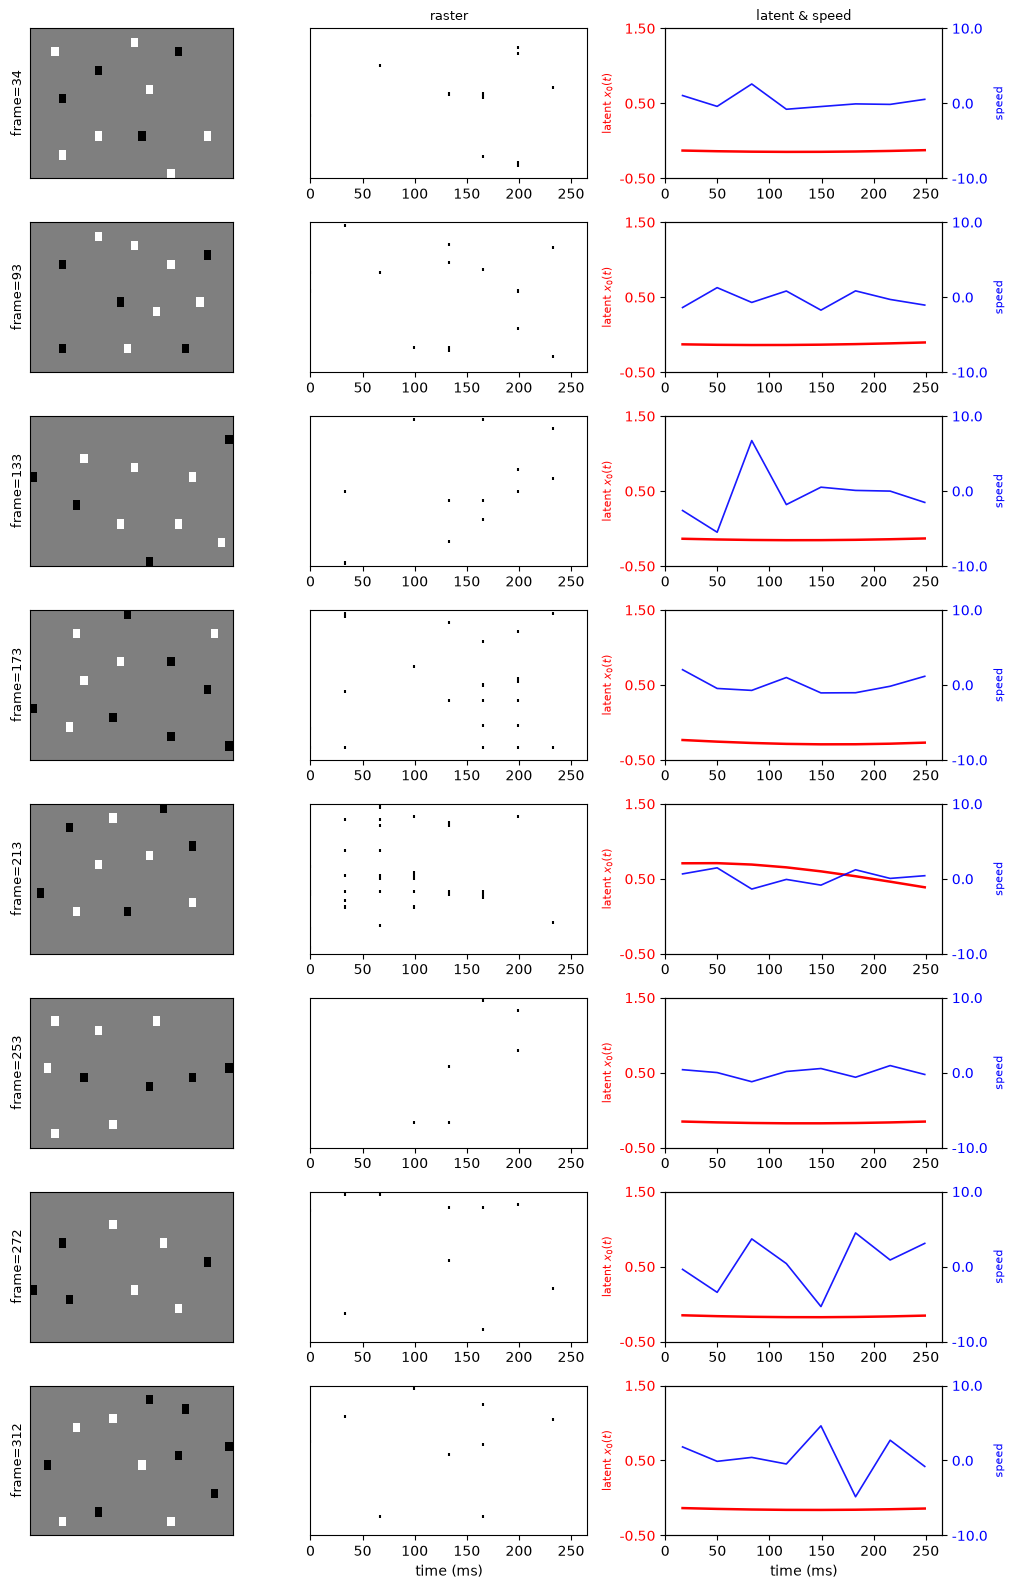

In [123]:
fig, axs = plot_grouped_gpfa(
    fit=fit_locally_sparse_noise,
    data_gpfa=data_locally_sparse_noise,
    raw_data=data,
    parameter="frame",
    trial_index=0,
    latent_dim=0,
    figsize=(1.25, 2),
    latent_ylim=(-0.5, 1.5),
    speed_ylim=(-10, 10),
)
plt.show()